In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import os
import zipfile
import io
import warnings

warnings.filterwarnings('ignore')

# --- 1. 路徑設定 (雲端硬碟掛載) ---
if not os.path.exists('/content/drive/MyDrive'):
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)

base_path = "/content/drive/MyDrive/金融資料探勘"
index_file_path = os.path.join(base_path, "Index_411121267_2023.csv")
master_zip_path = os.path.join(base_path, "Option_2023.zip")

# 輸出四個目標檔案
out_f1 = os.path.join(base_path, "Options_IV_Summary_2023.csv")
out_f2 = os.path.join(base_path, "Call_IV_Details_2023.csv")
out_f3 = os.path.join(base_path, "Put_IV_Details_2023.csv")
out_f4 = os.path.join(base_path, "PCR_Report_2023.csv")

# --- 2. Black-Scholes 模型與二分法 ---
def black_scholes(S, K, T, r, sigma, option_type='C'):
    if sigma <= 0 or S <= 0 or K <= 0 or T <= 0: return 0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == 'C':
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

def find_iv(market_price, S, K, T, r, option_type='C'):
    if market_price <= 0: return 0
    intrinsic = max(0, S - K) if option_type == 'C' else max(0, K * np.exp(-r * T) - S)
    if market_price <= intrinsic: return 0.0001
    low, high = 0.0001, 3.0
    for _ in range(35):
        mid = (low + high) / 2
        price = black_scholes(S, K, T, r, mid, option_type)
        if price < market_price: low = mid
        else: high = mid
    return mid

# --- 3. 🎯 融合關鍵：智能穿透壓縮檔工具 ---
def smart_read_csv(zip_stream, date_str):
    """從記憶體中的壓縮流，找出特定日期的 CSV 檔案並讀取"""
    with zipfile.ZipFile(zip_stream, 'r') as z:
        all_names = z.namelist()

        # 尋找 CSV 檔 (無底線比對)
        csv_matches = [n for n in all_names if date_str in n.replace("_", "") and n.endswith('.csv')]
        if csv_matches:
            with z.open(csv_matches[0]) as f:
                content = f.read()
                for enc in ['big5', 'utf-8-sig', 'gbk']:
                    try:
                        df = pd.read_csv(io.BytesIO(content), encoding=enc, low_memory=False)
                        if '商品代號' not in "".join(df.columns.astype(str)):
                             df = pd.read_csv(io.BytesIO(content), encoding=enc, skiprows=1, low_memory=False)
                        return df
                    except: continue

        # 尋找內層 ZIP 檔 (處理 1-6 月的雙層壓縮)
        zip_matches = [n for n in all_names if date_str in n.replace("_", "") and n.endswith('.zip')]
        if zip_matches:
            with z.open(zip_matches[0]) as f:
                return smart_read_csv(io.BytesIO(f.read()), date_str)
    return None

# --- 4. 核心處理程序 ---
def process_2023_all_in_one():
    print(f"🔎 正在讀取索引檔...")
    if not os.path.exists(index_file_path) or not os.path.exists(master_zip_path):
        print("❌ 找不到索引檔或主壓縮檔 Option_2023.zip，請確認路徑。")
        return

    try:
        df_index = pd.read_csv(index_file_path, encoding='utf-8-sig')
    except:
        df_index = pd.read_csv(index_file_path, encoding='big5')

    df_index.columns = df_index.columns.str.strip()
    if 'Date' in df_index.columns[0]: df_index.rename(columns={df_index.columns[0]: 'Date'}, inplace=True)

    all_details = []
    print(f"🚀 開始自動穿透 Option_2023.zip 處理數據...")

    with zipfile.ZipFile(master_zip_path, 'r') as master_zip:
        master_list = master_zip.namelist()

        for _, row in df_index.iterrows():
            date_str = str(row['Date']).replace("-", "").replace("/", "").strip()
            month_str = date_str[4:6]

            s0, rf = float(str(row['S0']).replace(',', '')), float(row['Rf'])
            t_years = float(row['Maturity']) / 365.0
            target_contract = str(row['Contract']).strip()
            expiry_date = str(row['ContractExpiryDate']).strip()

            print(f"[{date_str}] 處理中...", end=" ")
            raw_df = None

            # --- 🎯 智慧尋路邏輯 ---
            if int(month_str) >= 7:
                monthly_zip_match = [p for p in master_list if f"2023_{month_str}.zip" in p]
                if monthly_zip_match:
                    with master_zip.open(monthly_zip_match[0]) as mz:
                        raw_df = smart_read_csv(io.BytesIO(mz.read()), date_str)
            else:
                daily_zip_match = [p for p in master_list if date_str in p.replace("_", "") and p.endswith('.zip')]
                if daily_zip_match:
                    with master_zip.open(daily_zip_match[0]) as dz:
                        raw_df = smart_read_csv(io.BytesIO(dz.read()), date_str)

            # --- 進行資料過濾與 IV 計算 ---
            if raw_df is not None:
                raw_df.columns = raw_df.columns.astype(str).str.strip()
                if '商品代號' in raw_df.columns: raw_df['商品代號'] = raw_df['商品代號'].str.strip()
                if '買賣權別' in raw_df.columns: raw_df['買賣權別'] = raw_df['買賣權別'].astype(str).str.strip()

                for col in ['履約價格', '成交價格', '成交數量(B or S)']:
                    if col in raw_df.columns:
                        raw_df[col] = pd.to_numeric(raw_df[col], errors='coerce')

                # 篩選條件：TXO、目標合約、成交量 > 30 (不分 CP，因為要產出明細)
                mask = (raw_df['商品代號'] == 'TXO') & \
                       (raw_df['到期月份(週別)'].astype(str).str.contains(target_contract)) & \
                       (raw_df['成交數量(B or S)'] > 30) & \
                       (raw_df['買賣權別'].isin(['C', 'P']))

                df_filtered = raw_df[mask].copy()

                if not df_filtered.empty:
                    # 逐筆計算 IV
                    for idx, opt_row in df_filtered.iterrows():
                        iv = find_iv(opt_row['成交價格'], s0, opt_row['履約價格'], t_years, rf, opt_row['買賣權別'])

                        all_details.append({
                            'Date': row['Date'],
                            'File': f"o{date_str}.csv",
                            'S0': s0,
                            'Contract': target_contract,
                            '買賣權別': opt_row['買賣權別'],
                            'ContractExpiryDate': expiry_date,
                            'Rf': rf,
                            '履約價格': opt_row['履約價格'],
                            '成交價格': opt_row['成交價格'],
                            '成交數量(B or S)': opt_row['成交數量(B or S)'], # 為了算 Volume PCR 預留
                            'Implied_Volatility': iv
                        })
                    print(f"✅ 完成 ({len(df_filtered)} 筆交易)")
                else:
                    print("⚠️ 無符合條件交易")
            else:
                print("❌ 找不到檔案")

    # --- 5. 產出報表 ---
    if not all_details:
        print("\n❌ 失敗：整年度未提取到任何符合條件的資料。")
        return

    print("\n📊 正在產出四大報表...")
    df_main = pd.DataFrame(all_details)

    # 1. 總摘要表
    df_main.groupby('Date')['Implied_Volatility'].describe().to_csv(out_f1, encoding='utf-8-sig')

    # 2 & 3. 買賣權明細
    cols = ['Date', 'File', 'S0', 'Contract', '買賣權別', 'ContractExpiryDate', 'Rf', '履約價格', '成交價格', 'Implied_Volatility']
    for cp, path in [('C', out_f2), ('P', out_f3)]:
        df_main[df_main['買賣權別'] == cp][cols].to_csv(path, index=False, encoding='utf-8-sig')

    # 4. PCR 綜合報表 (包含 Volume 與 Count)
    # 先算 IV 的 Mean, Std 和 Count (過濾掉算不出 IV 的 NaN 資料)
    stats_iv = df_main.dropna(subset=['Implied_Volatility']).groupby(['Date', '買賣權別'])['Implied_Volatility'].agg(['mean', 'std', 'count']).unstack()

    # 另外算真實成交量 (Volume) 的總和
    stats_vol = df_main.groupby(['Date', '買賣權別'])['成交數量(B or S)'].sum().unstack()

    pcr = pd.DataFrame(index=stats_iv.index)

    # 寫入統計資料 (補 0 避免缺漏)
    pcr['Call_IV_Mean'], pcr['Put_IV_Mean'] = stats_iv[('mean', 'C')], stats_iv[('mean', 'P')]
    pcr['Call_IV_Std'], pcr['Put_IV_Std'] = stats_iv[('std', 'C')], stats_iv[('std', 'P')]
    pcr['Call_Count'], pcr['Put_Count'] = stats_iv[('count', 'C')].fillna(0), stats_iv[('count', 'P')].fillna(0)
    pcr['Call_Volume'], pcr['Put_Volume'] = stats_vol['C'].fillna(0), stats_vol['P'].fillna(0)

    # 計算兩種 PCR
    pcr['PCR (Trade Count)'] = np.where(pcr['Call_Count'] == 0, np.nan, pcr['Put_Count'] / pcr['Call_Count'])
    pcr['PCR (Volume)'] = np.where(pcr['Call_Volume'] == 0, np.nan, pcr['Put_Volume'] / pcr['Call_Volume'])

    pcr.to_csv(out_f4, encoding='utf-8-sig')

    print(f"🎉 大功告成！四個分析報表已直接寫入金融資料探勘資料夾。")

process_2023_all_in_one()

Mounted at /content/drive
🔎 正在讀取索引檔...
🚀 開始自動穿透 Option_2023.zip 處理數據...
[20230103] 處理中... ✅ 完成 (7621 筆交易)
[20230104] 處理中... ✅ 完成 (6953 筆交易)
[20230105] 處理中... ✅ 完成 (2378 筆交易)
[20230106] 處理中... ✅ 完成 (3525 筆交易)
[20230109] 處理中... ✅ 完成 (7182 筆交易)
[20230110] 處理中... ✅ 完成 (6237 筆交易)
[20230111] 處理中... ✅ 完成 (7650 筆交易)
[20230112] 處理中... ✅ 完成 (1558 筆交易)
[20230113] 處理中... ✅ 完成 (3014 筆交易)
[20230116] 處理中... ✅ 完成 (2298 筆交易)
[20230117] 處理中... ✅ 完成 (1818 筆交易)
[20230130] 處理中... ✅ 完成 (845 筆交易)
[20230131] 處理中... ✅ 完成 (4148 筆交易)
[20230201] 處理中... ✅ 完成 (5512 筆交易)
[20230202] 處理中... ✅ 完成 (3015 筆交易)
[20230203] 處理中... ✅ 完成 (2638 筆交易)
[20230206] 處理中... ✅ 完成 (3560 筆交易)
[20230207] 處理中... ✅ 完成 (4584 筆交易)
[20230208] 處理中... ✅ 完成 (6662 筆交易)
[20230209] 處理中... ✅ 完成 (2108 筆交易)
[20230210] 處理中... ✅ 完成 (3519 筆交易)
[20230213] 處理中... ✅ 完成 (4042 筆交易)
[20230214] 處理中... ✅ 完成 (3495 筆交易)
[20230215] 處理中... ✅ 完成 (417 筆交易)
[20230216] 處理中... ✅ 完成 (727 筆交易)
[20230217] 處理中... ✅ 完成 (372 筆交易)
[20230220] 處理中... ✅ 完成 (536 筆交易)
[20230221] 處理中.

###X光診斷程式

In [ ]:
import pandas as pd
import zipfile
import io
import os

# ==========================================
# 1. 設定路徑與目標日期
# ==========================================
base_path = "/content/drive/MyDrive/金融資料探勘"
master_zip_path = os.path.join(base_path, "Option_2023.zip")
target_date = "20230103"  # 鎖定異常的第一天
target_contract = "202301" # 假設您的 Index 檔這天指定的是 202301

print(f"🔍 開始診斷 {target_date} 的原始資料...\n")

# ==========================================
# 2. 鑽取原始檔案
# ==========================================
raw_df = None
with zipfile.ZipFile(master_zip_path, 'r') as master_zip:
    master_list = master_zip.namelist()
    # 找出 20230103 的壓縮檔
    daily_zip_match = [p for p in master_list if target_date in p.replace("_", "") and p.endswith('.zip')]

    if daily_zip_match:
        with master_zip.open(daily_zip_match[0]) as dz:
            with zipfile.ZipFile(io.BytesIO(dz.read()), 'r') as inner_zip:
                csv_name = [n for n in inner_zip.namelist() if n.endswith('.csv')][0]
                with inner_zip.open(csv_name) as f:
                    content = f.read()
                    for enc in ['big5', 'utf-8-sig', 'gbk']:
                        try:
                            raw_df = pd.read_csv(io.BytesIO(content), encoding=enc, low_memory=False)
                            if '商品代號' not in "".join(raw_df.columns.astype(str)):
                                raw_df = pd.read_csv(io.BytesIO(content), encoding=enc, skiprows=1, low_memory=False)
                            break
                        except: continue

if raw_df is None:
    print("❌ 找不到原始資料！")
else:
    # ==========================================
    # 3. 開始 X 光掃描
    # ==========================================
    # 清洗基本欄位名稱
    raw_df.columns = raw_df.columns.astype(str).str.strip()
    if '商品代號' in raw_df.columns: raw_df['商品代號'] = raw_df['商品代號'].str.strip()
    if '買賣權別' in raw_df.columns: raw_df['買賣權別'] = raw_df['買賣權別'].astype(str).str.strip()

    for col in ['成交數量(B or S)']:
        raw_df[col] = pd.to_numeric(raw_df[col], errors='coerce').fillna(0)

    # 針對 TXO 進行初步過濾
    df_txo = raw_df[raw_df['商品代號'] == 'TXO'].copy()

    print("📊 [檢驗 1] TXO 最原始的總成交量 (未經任何篩選):")
    total_call = df_txo[df_txo['買賣權別'] == 'C']['成交數量(B or S)'].sum()
    total_put = df_txo[df_txo['買賣權別'] == 'P']['成交數量(B or S)'].sum()
    print(f"   ➤ Call 總成交量: {total_call:,.0f}")
    print(f"   ➤ Put 總成交量: {total_put:,.0f}")
    print(f"   ➤ 原始真實 PCR: {total_put / total_call if total_call > 0 else 0:.2f}\n")

    print("👀 [檢驗 2] '買賣權別' 欄位到底有哪些奇怪的值？")
    print(f"   ➤ {df_txo['買賣權別'].unique().tolist()}\n")

    print("👀 [檢驗 3] TXO '到期月份(週別)' 的真實長相 (前 10 種):")
    contracts = df_txo['到期月份(週別)'].unique()
    print(f"   ➤ {contracts[:10].tolist()}\n")

    print("🔪 [檢驗 4] 篩選條件生存測試 (合約: {})".format(target_contract))

    # 測試 Call 的存活率
    call_mask_1 = (df_txo['買賣權別'] == 'C')
    call_mask_2 = call_mask_1 & (df_txo['成交數量(B or S)'] > 30)
    call_mask_3 = call_mask_2 & (df_txo['到期月份(週別)'].astype(str).str.contains(target_contract))

    print(f"   [Call 買權]")
    print(f"   1. 是 C 的資料筆數: {call_mask_1.sum()} 筆")
    print(f"   2. 加上 '成交量>30' 後剩餘: {call_mask_2.sum()} 筆")
    print(f"   3. 加上 '包含 {target_contract}' 後剩餘: {call_mask_3.sum()} 筆  <-- 兇手通常在這裡！\n")

    # 測試 Put 的存活率
    put_mask_1 = (df_txo['買賣權別'] == 'P')
    put_mask_2 = put_mask_1 & (df_txo['成交數量(B or S)'] > 30)
    put_mask_3 = put_mask_2 & (df_txo['到期月份(週別)'].astype(str).str.contains(target_contract))

    print(f"   [Put 賣權]")
    print(f"   1. 是 P 的資料筆數: {put_mask_1.sum()} 筆")
    print(f"   2. 加上 '成交量>30' 後剩餘: {put_mask_2.sum()} 筆")
    print(f"   3. 加上 '包含 {target_contract}' 後剩餘: {put_mask_3.sum()} 筆")

🔍 開始診斷 20230103 的原始資料...

📊 [檢驗 1] TXO 最原始的總成交量 (未經任何篩選):
   ➤ Call 總成交量: 993,542
   ➤ Put 總成交量: 986,702
   ➤ 原始真實 PCR: 0.99

👀 [檢驗 2] '買賣權別' 欄位到底有哪些奇怪的值？
   ➤ ['P', 'C']

👀 [檢驗 3] TXO '到期月份(週別)' 的真實長相 (前 10 種):
   ➤ ['    202303  ', '    202306  ', '    202301  ', '    202309  ', '    202302  ', '    202301W1  ', '    202301W2  ']

🔪 [檢驗 4] 篩選條件生存測試 (合約: 202301)
   [Call 買權]
   1. 是 C 的資料筆數: 243258 筆
   2. 加上 '成交量>30' 後剩餘: 3747 筆
   3. 加上 '包含 202301' 後剩餘: 3734 筆  <-- 兇手通常在這裡！

   [Put 賣權]
   1. 是 P 的資料筆數: 245352 筆
   2. 加上 '成交量>30' 後剩餘: 3890 筆
   3. 加上 '包含 202301' 後剩餘: 3887 筆


###圖表

⏳ 正在下載中文字體，請稍候...


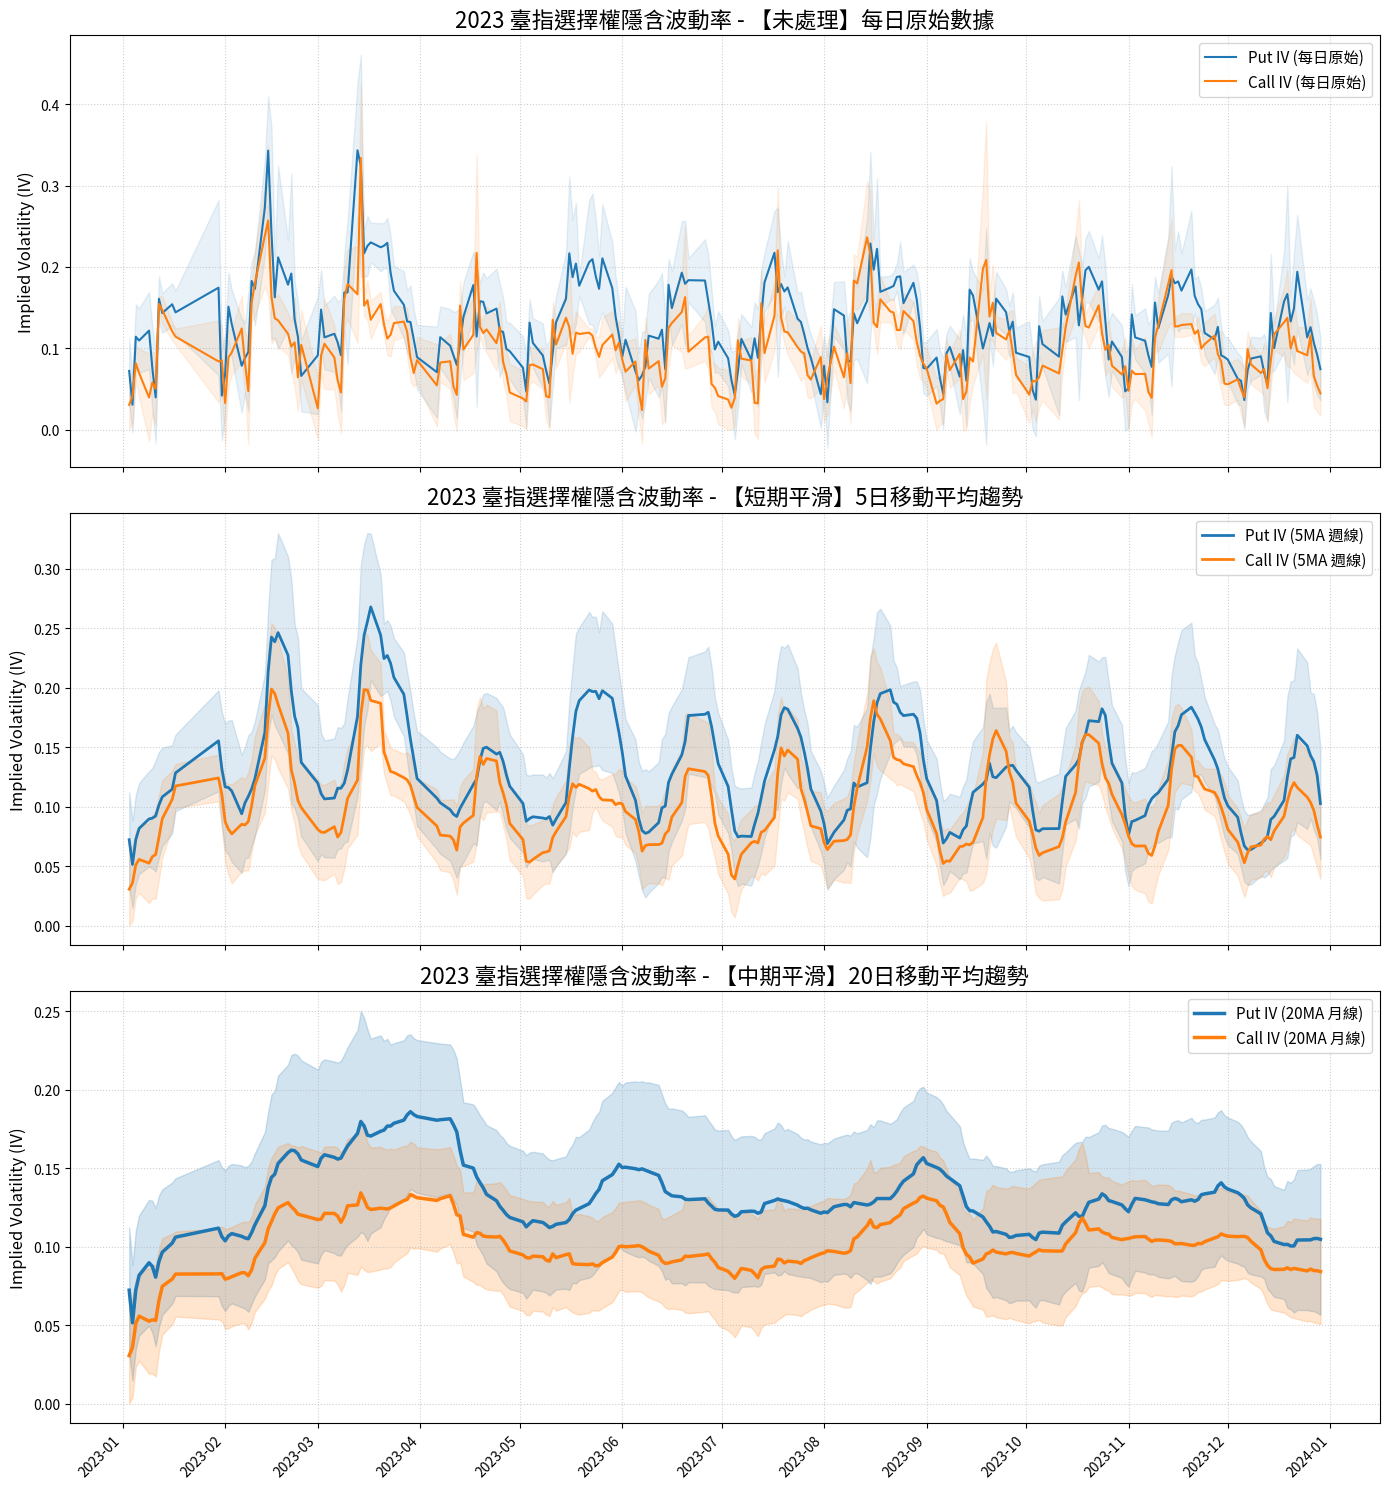

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import urllib.request
import matplotlib.font_manager as fm

# --- 0. 解決 Colab 中文字體亂碼問題 ---
font_url = "https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf"
font_path = "NotoSansCJKtc-Regular.otf"
if not os.path.exists(font_path):
    print("⏳ 正在下載中文字體，請稍候...")
    urllib.request.urlretrieve(font_url, font_path)
fm.fontManager.addfont(font_path)
plt.rc('font', family='Noto Sans CJK TC')
plt.rcParams['axes.unicode_minus'] = False

# --- 1. 讀取最終報表資料 ---
base_path = "/content/drive/MyDrive/金融資料探勘"
report_file = os.path.join(base_path, "PCR_Report_2023.csv")
df = pd.read_csv(report_file)

# 將 Date 轉為 datetime 格式，並設為索引
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# --- 2. 計算 5 日與 20 日移動平均 ---
df_5ma = df.rolling(window=5, min_periods=1).mean()
df_20ma = df.rolling(window=20, min_periods=1).mean()

# --- 3. 開始繪圖設定 (三張子圖，共用 X 軸) ---
# 將圖表高度拉長至 15，容納三張圖
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 15), sharex=True)
x = df.index

# ==========================================
# 【上圖 (ax1)：每日原始數據 (充滿雜訊)】
# ==========================================
ax1.plot(x, df['Put_IV_Mean'], color='tab:blue', linewidth=1.5, label='Put IV (每日原始)')
ax1.plot(x, df['Call_IV_Mean'], color='tab:orange', linewidth=1.5, label='Call IV (每日原始)')
# 畫出原始數據的標準差範圍
ax1.fill_between(x, df['Put_IV_Mean'] - df['Put_IV_Std'], df['Put_IV_Mean'] + df['Put_IV_Std'], color='tab:blue', alpha=0.1)
ax1.fill_between(x, df['Call_IV_Mean'] - df['Call_IV_Std'], df['Call_IV_Mean'] + df['Call_IV_Std'], color='tab:orange', alpha=0.1)

ax1.set_title('2023 臺指選擇權隱含波動率 - 【未處理】每日原始數據', fontsize=16, fontweight='bold')
ax1.set_ylabel('Implied Volatility (IV)', fontsize=12)
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.6)

# ==========================================
# 【中圖 (ax2)：5MA 平滑趨勢 (短期情緒)】
# ==========================================
ax2.plot(x, df_5ma['Put_IV_Mean'], color='tab:blue', linewidth=2.0, label='Put IV (5MA 週線)')
ax2.plot(x, df_5ma['Call_IV_Mean'], color='tab:orange', linewidth=2.0, label='Call IV (5MA 週線)')
# 畫出 5MA 的標準差範圍
ax2.fill_between(x, df_5ma['Put_IV_Mean'] - df_5ma['Put_IV_Std'], df_5ma['Put_IV_Mean'] + df_5ma['Put_IV_Std'], color='tab:blue', alpha=0.15)
ax2.fill_between(x, df_5ma['Call_IV_Mean'] - df_5ma['Call_IV_Std'], df_5ma['Call_IV_Mean'] + df_5ma['Call_IV_Std'], color='tab:orange', alpha=0.15)

ax2.set_title('2023 臺指選擇權隱含波動率 - 【短期平滑】5日移動平均趨勢', fontsize=16, fontweight='bold')
ax2.set_ylabel('Implied Volatility (IV)', fontsize=12)
ax2.legend(loc='upper right', fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.6)

# ==========================================
# 【下圖 (ax3)：20MA 平滑趨勢 (中期核心)】
# ==========================================
ax3.plot(x, df_20ma['Put_IV_Mean'], color='tab:blue', linewidth=2.5, label='Put IV (20MA 月線)')
ax3.plot(x, df_20ma['Call_IV_Mean'], color='tab:orange', linewidth=2.5, label='Call IV (20MA 月線)')
# 畫出 20MA 的標準差範圍
ax3.fill_between(x, df_20ma['Put_IV_Mean'] - df_20ma['Put_IV_Std'], df_20ma['Put_IV_Mean'] + df_20ma['Put_IV_Std'], color='tab:blue', alpha=0.2)
ax3.fill_between(x, df_20ma['Call_IV_Mean'] - df_20ma['Call_IV_Std'], df_20ma['Call_IV_Mean'] + df_20ma['Call_IV_Std'], color='tab:orange', alpha=0.2)

ax3.set_title('2023 臺指選擇權隱含波動率 - 【中期平滑】20日移動平均趨勢', fontsize=16, fontweight='bold')
ax3.set_ylabel('Implied Volatility (IV)', fontsize=12)
ax3.legend(loc='upper right', fontsize=11)
ax3.grid(True, linestyle=':', alpha=0.6)

# --- 4. 視覺化美化 ---
# 設定 X 軸的月份顯示格式
ax3.xaxis.set_major_locator(mdates.MonthLocator())
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate(rotation=45)

# 縮小圖之間的空白，讓對照更緊密
plt.subplots_adjust(hspace=0.2)
fig.tight_layout()

# 顯示圖表
plt.show()

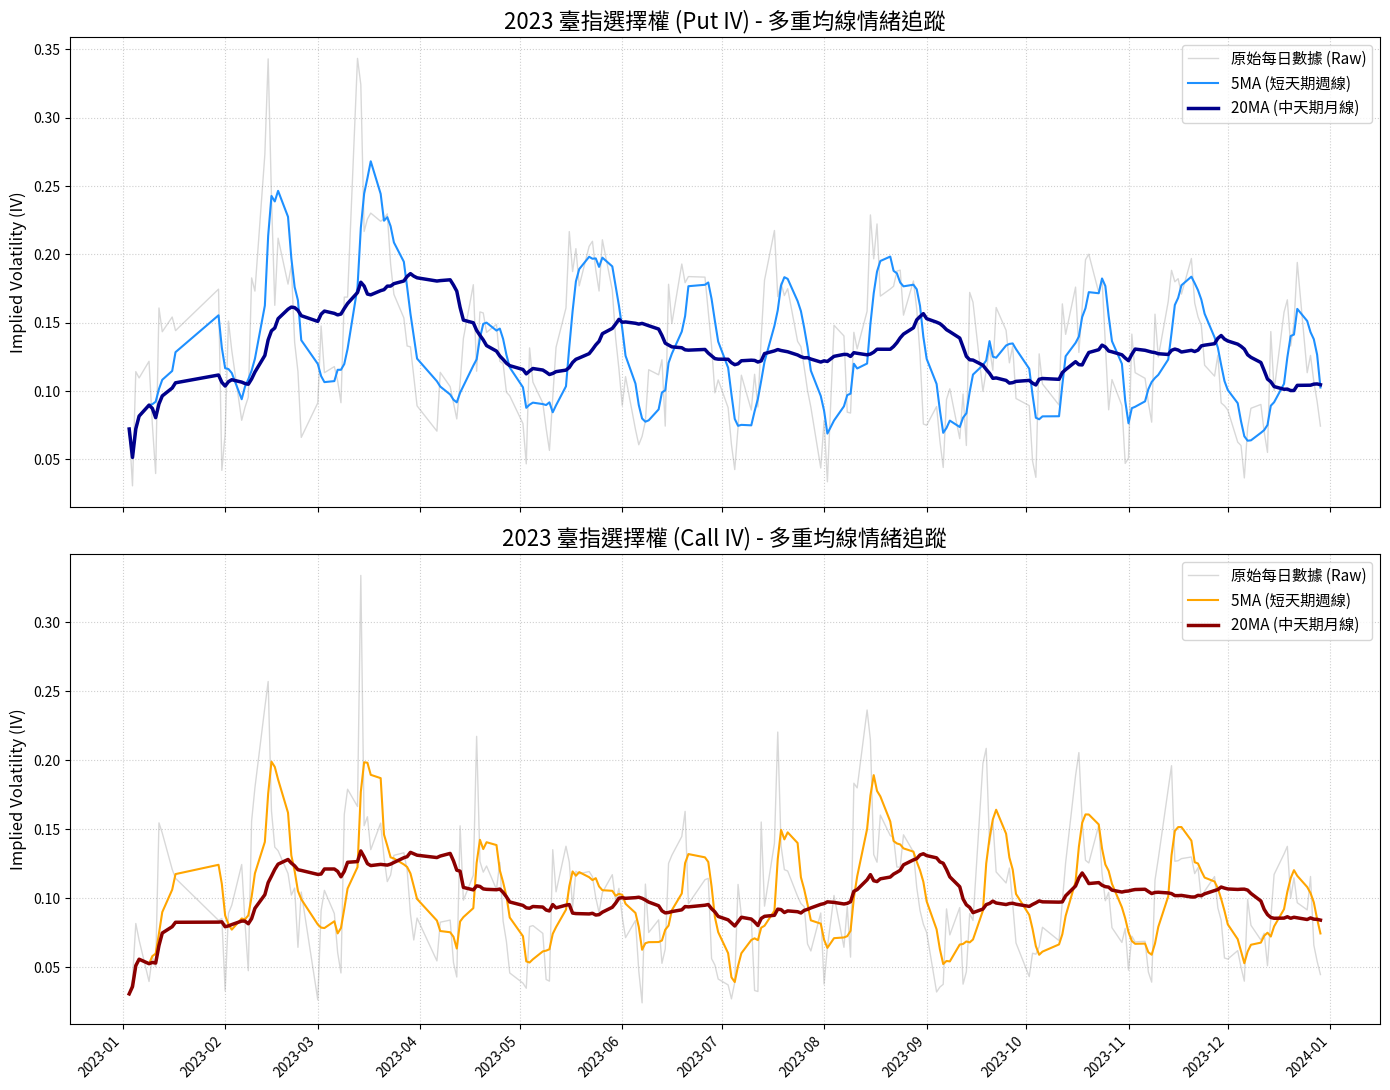

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import urllib.request
import matplotlib.font_manager as fm

# --- 0. 解決 Colab 中文字體亂碼問題 ---
font_url = "https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf"
font_path = "NotoSansCJKtc-Regular.otf"
if not os.path.exists(font_path):
    print("⏳ 正在下載中文字體，請稍候...")
    urllib.request.urlretrieve(font_url, font_path)
fm.fontManager.addfont(font_path)
plt.rc('font', family='Noto Sans CJK TC')
plt.rcParams['axes.unicode_minus'] = False

# --- 1. 讀取最終報表資料 ---
base_path = "/content/drive/MyDrive/金融資料探勘"
report_file = os.path.join(base_path, "PCR_Report_2023.csv")
df = pd.read_csv(report_file)

# 將 Date 轉為 datetime 格式，並設為索引
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# --- 2. 計算 5MA (週線) 與 20MA (月線) ---
df_5ma = df.rolling(window=5, min_periods=1).mean()
df_20ma = df.rolling(window=20, min_periods=1).mean()

# --- 3. 開始繪圖設定 (上下子圖：Put 與 Call 分開展示) ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 11), sharex=True)
x = df.index

# ==========================================
# 【上圖 (ax1)：Put IV (看跌/避險情緒)】
# ==========================================
# 1. 原始數據 (使用淺灰色與高透明度作為背景底噪)
ax1.plot(x, df['Put_IV_Mean'], color='gray', linewidth=1, alpha=0.3, label='原始每日數據 (Raw)')
# 2. 5MA 週線 (使用亮藍色，反映短期情緒波動)
ax1.plot(x, df_5ma['Put_IV_Mean'], color='dodgerblue', linewidth=1.5, label='5MA (短天期週線)')
# 3. 20MA 月線 (使用深藍色加粗，反映中期核心趨勢)
ax1.plot(x, df_20ma['Put_IV_Mean'], color='darkblue', linewidth=2.5, label='20MA (中天期月線)')

ax1.set_title('2023 臺指選擇權 (Put IV) - 多重均線情緒追蹤', fontsize=16, fontweight='bold')
ax1.set_ylabel('Implied Volatility (IV)', fontsize=12)
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.6)

# ==========================================
# 【下圖 (ax2)：Call IV (看漲/追價情緒)】
# ==========================================
# 1. 原始數據 (背景底噪)
ax2.plot(x, df['Call_IV_Mean'], color='gray', linewidth=1, alpha=0.3, label='原始每日數據 (Raw)')
# 2. 5MA 週線 (使用亮橘色)
ax2.plot(x, df_5ma['Call_IV_Mean'], color='orange', linewidth=1.5, label='5MA (短天期週線)')
# 3. 20MA 月線 (使用深紅色加粗)
ax2.plot(x, df_20ma['Call_IV_Mean'], color='darkred', linewidth=2.5, label='20MA (中天期月線)')

ax2.set_title('2023 臺指選擇權 (Call IV) - 多重均線情緒追蹤', fontsize=16, fontweight='bold')
ax2.set_ylabel('Implied Volatility (IV)', fontsize=12)
ax2.legend(loc='upper right', fontsize=11)
ax2.grid(True, linestyle=':', alpha=0.6)

# --- 4. 視覺化美化 ---
# 設定 X 軸的月份顯示格式
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate(rotation=45)

# 縮小兩張圖之間的空白
plt.subplots_adjust(hspace=0.15)
fig.tight_layout()

# 顯示圖表
plt.show()

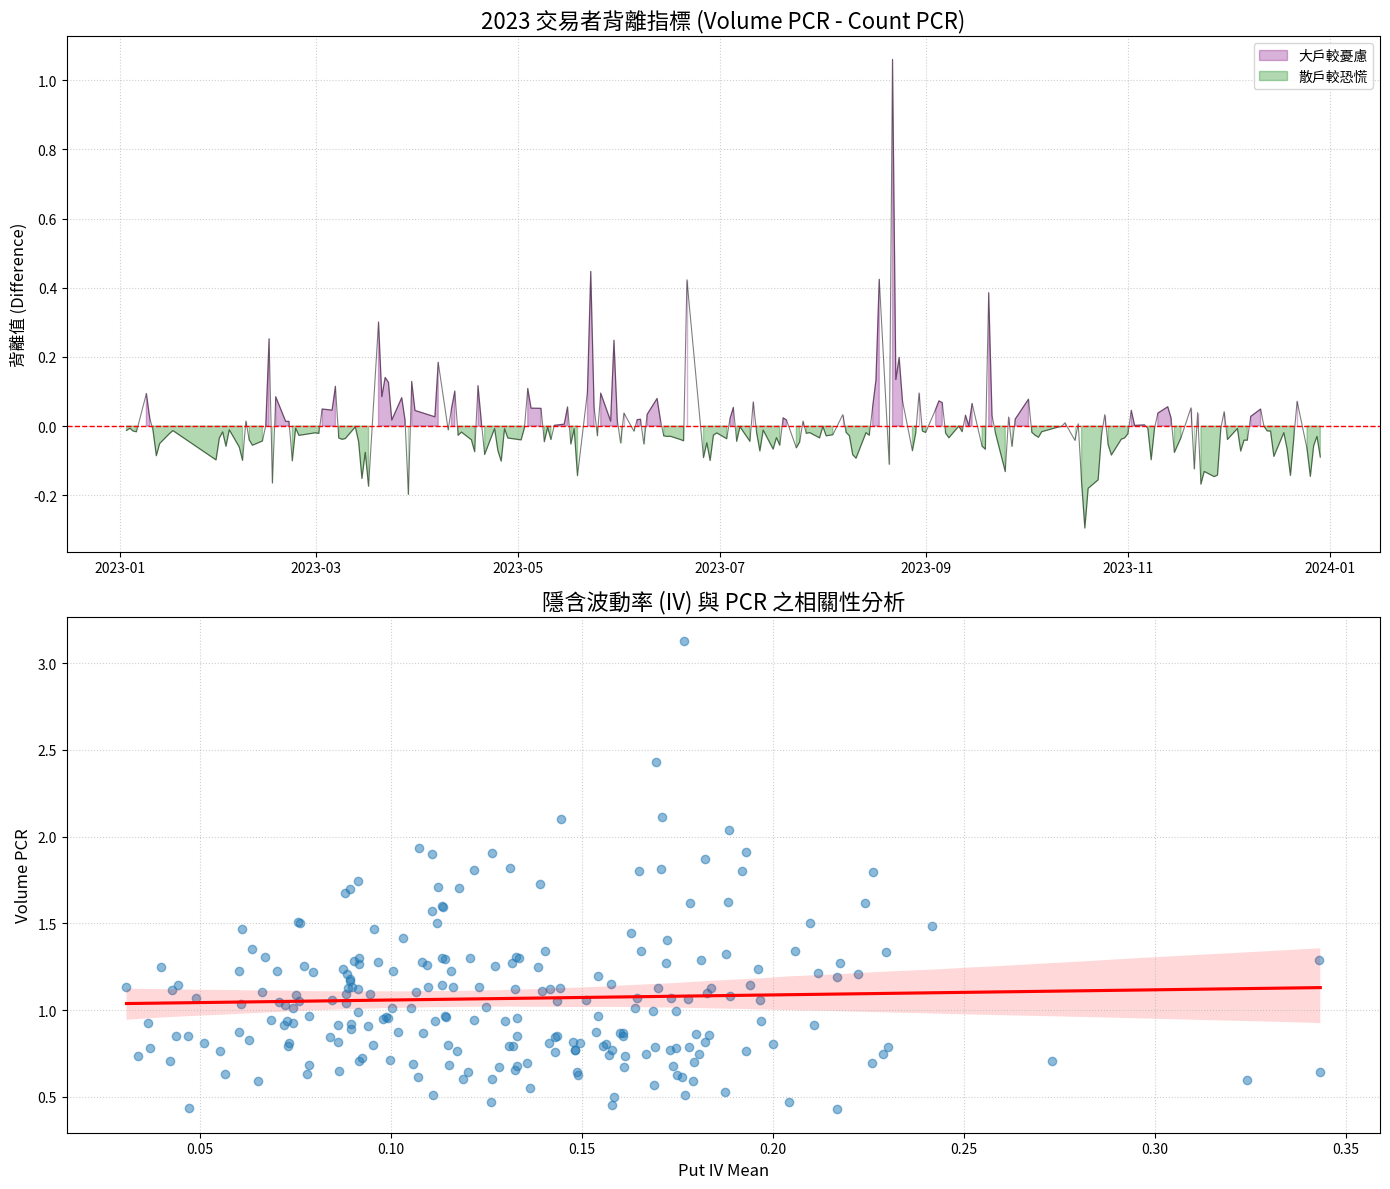

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. 讀取報表 ---
base_path = "/content/drive/MyDrive/金融資料探勘"
df = pd.read_csv(os.path.join(base_path, "PCR_Report_2023.csv"))
df['Date'] = pd.to_datetime(df['Date'])

# --- 2. 計算背離值 (Divergence) ---
df['PCR_Diff'] = df['PCR (Volume)'] - df['PCR (Trade Count)']

# --- 3. 開始繪圖 (1x2 子圖) ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# 【圖一：大戶 vs 散戶背離走勢】
# 填色：正值區域(大戶偏空)用紫色，負值區域(散戶偏空)用綠色
ax1.fill_between(df['Date'], df['PCR_Diff'], 0, where=(df['PCR_Diff'] >= 0), color='purple', alpha=0.3, label='大戶較憂慮')
ax1.fill_between(df['Date'], df['PCR_Diff'], 0, where=(df['PCR_Diff'] < 0), color='green', alpha=0.3, label='散戶較恐慌')
ax1.plot(df['Date'], df['PCR_Diff'], color='black', linewidth=0.8, alpha=0.5)
ax1.axhline(0, color='red', linestyle='--', linewidth=1)

ax1.set_title('2023 交易者背離指標 (Volume PCR - Count PCR)', fontsize=16, fontweight='bold')
ax1.set_ylabel('背離值 (Difference)', fontsize=12)
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)

# 【圖二：IV 與 PCR 的相關性散佈圖】
# 使用 Put IV 與 Volume PCR 來觀察避險群體的行為
sns.regplot(x=df['Put_IV_Mean'], y=df['PCR (Volume)'], ax=ax2,
            scatter_kws={'alpha':0.5, 'color':'tab:blue'}, line_kws={'color':'red'})

ax2.set_title('隱含波動率 (IV) 與 PCR 之相關性分析', fontsize=16, fontweight='bold')
ax2.set_xlabel('Put IV Mean', fontsize=12)
ax2.set_ylabel('Volume PCR', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

📈 正在下載台股加權指數資料...


/tmp/ipykernel_1863/4218677845.py:28: FutureWarning: YF.download() has changed argument auto_adjust default to True
  twii = yf.download('^TWII', start='2023-01-01', end='2023-12-31', progress=False)


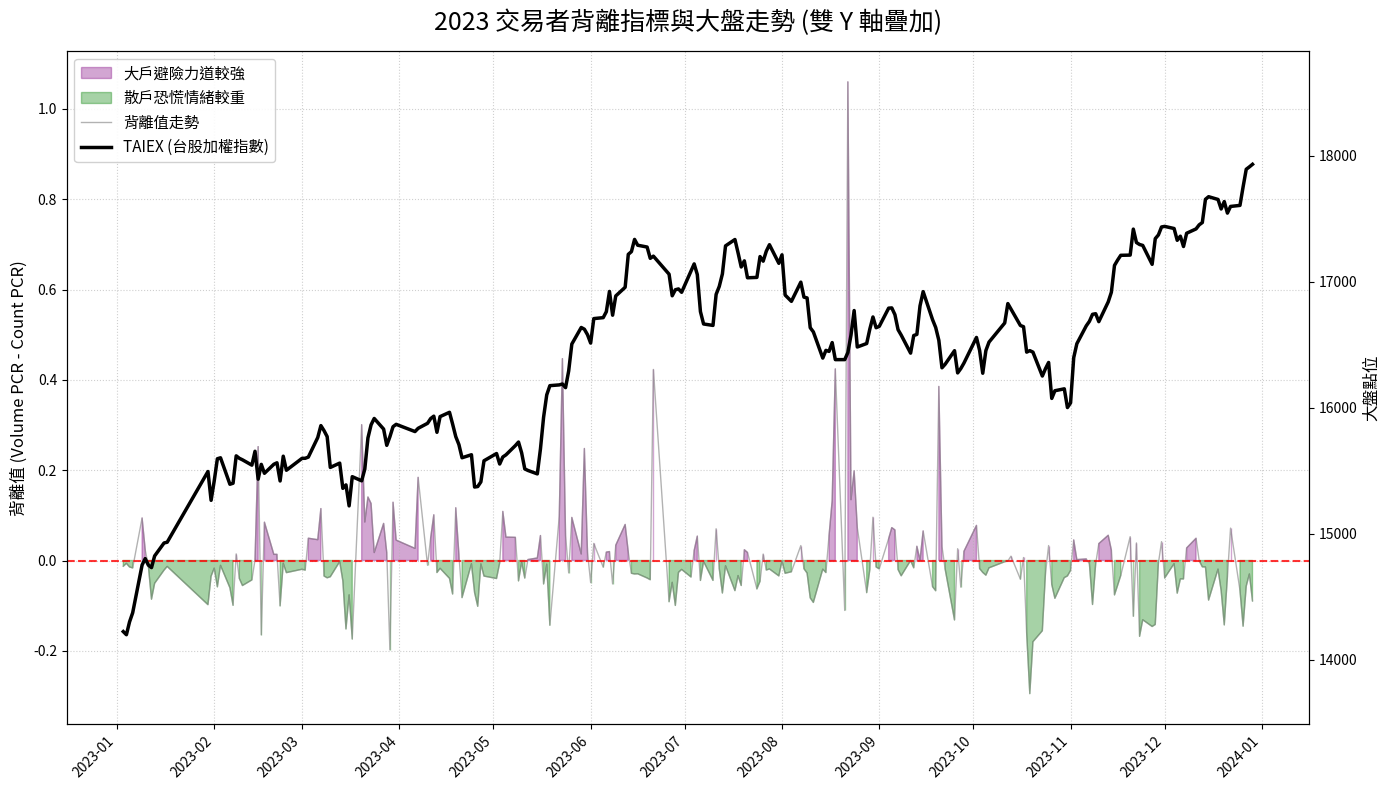

In [10]:
# !pip install yfinance

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
import os
import urllib.request
import matplotlib.font_manager as fm

# --- 0. 解決 Colab 中文字體亂碼問題 ---
font_url = "https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf"
font_path = "NotoSansCJKtc-Regular.otf"
if not os.path.exists(font_path):
    print("⏳ 正在下載中文字體...")
    urllib.request.urlretrieve(font_url, font_path)
fm.fontManager.addfont(font_path)
plt.rc('font', family='Noto Sans CJK TC')
plt.rcParams['axes.unicode_minus'] = False

# --- 1. 讀取報表與下載大盤資料 ---
base_path = "/content/drive/MyDrive/金融資料探勘"
df = pd.read_csv(os.path.join(base_path, "PCR_Report_2023.csv"))
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

print("📈 正在下載台股加權指數資料...")
twii = yf.download('^TWII', start='2023-01-01', end='2023-12-31', progress=False)
twii_close = twii['Close'].squeeze()

# --- 2. 計算背離指標 (Divergence) ---
# 背離值 = 大戶(Volume) - 散戶(Count)
df['PCR_Diff'] = df['PCR (Volume)'] - df['PCR (Trade Count)']

# --- 3. 開始繪圖 (單圖雙 Y 軸直接疊加) ---
fig, ax1 = plt.subplots(figsize=(14, 8))

# 【左邊 Y 軸 (ax1)：情緒背離指標 (色塊)】
# 紫色：大戶比散戶更憂慮；綠色：散戶比大戶更恐慌
fill_purple = ax1.fill_between(df.index, df['PCR_Diff'], 0, where=(df['PCR_Diff'] >= 0), color='purple', alpha=0.35, label='大戶避險力道較強')
fill_green = ax1.fill_between(df.index, df['PCR_Diff'], 0, where=(df['PCR_Diff'] < 0), color='green', alpha=0.35, label='散戶恐慌情緒較重')
line_diff, = ax1.plot(df.index, df['PCR_Diff'], color='gray', linewidth=1, alpha=0.6, label='背離值走勢')
ax1.axhline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.8)

ax1.set_ylabel('背離值 (Volume PCR - Count PCR)', fontsize=12, color='black')
ax1.tick_params(axis='y', labelcolor='black')

# 【右邊 Y 軸 (ax2)：台股加權指數 (黑線)】
ax2 = ax1.twinx()  # 建立共享 X 軸的第二個 Y 軸
line_twii, = ax2.plot(twii.index, twii_close, color='black', linewidth=2.5, label='TAIEX (台股加權指數)')

# 為了讓大盤線條不要跟色塊全擠在一起，稍微拉大右邊 Y 軸的上下限
ax2.set_ylim(twii_close.min() * 0.95, twii_close.max() * 1.05)
ax2.set_ylabel('大盤點位', fontsize=12, color='black')
ax2.tick_params(axis='y', labelcolor='black')

# --- 4. 視覺化美化與圖例整合 ---
ax1.set_title('2023 交易者背離指標與大盤走勢 (雙 Y 軸疊加)', fontsize=18, fontweight='bold', pad=15)

# 整合左右 Y 軸的圖例放在一起
handles = [fill_purple, fill_green, line_diff, line_twii]
labels = [h.get_label() for h in handles]
ax1.legend(handles, labels, loc='upper left', fontsize=11, framealpha=0.9)

# 設定 X 軸的月份顯示格式
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate(rotation=45)

ax1.grid(True, linestyle=':', alpha=0.6)
fig.tight_layout()

plt.show()

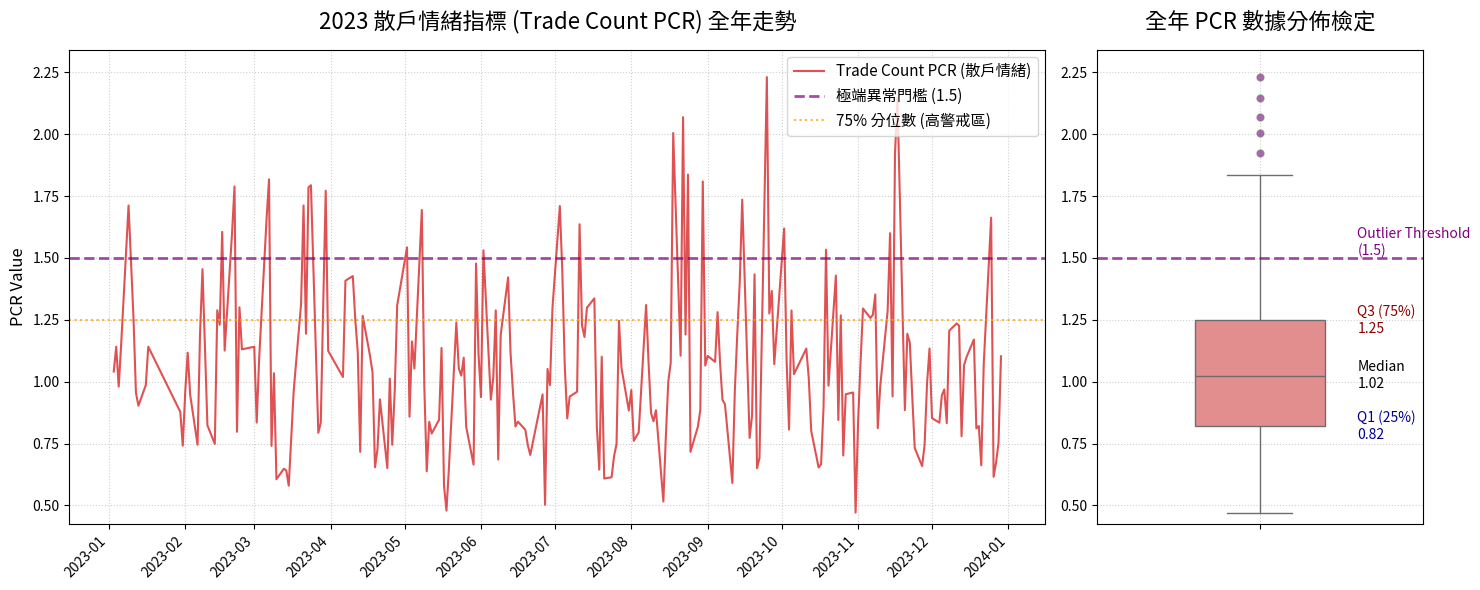

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os
import urllib.request
import matplotlib.font_manager as fm

# --- 0. 解決 Colab 中文字體亂碼問題 ---
font_url = "https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf"
font_path = "NotoSansCJKtc-Regular.otf"
if not os.path.exists(font_path):
    print("⏳ 正在下載中文字體，請稍候...")
    urllib.request.urlretrieve(font_url, font_path)
fm.fontManager.addfont(font_path)
plt.rc('font', family='Noto Sans CJK TC')
plt.rcParams['axes.unicode_minus'] = False

# --- 1. 讀取報表資料 ---
base_path = "/content/drive/MyDrive/金融資料探勘"
report_file = os.path.join(base_path, "PCR_Report_2023.csv")
df = pd.read_csv(report_file)

# 將 Date 轉為 datetime 格式，並設為索引
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# 鎖定我們要分析的欄位：散戶情緒 (Trade Count PCR)
pcr_series = df['PCR (Trade Count)'].dropna()

# 計算統計分位數
q1 = pcr_series.quantile(0.25)
median = pcr_series.median()
q3 = pcr_series.quantile(0.75)
iqr = q3 - q1
outlier_threshold = 1.5 # 您定義的異常門檻

# --- 2. 開始繪圖設定 (1x2 左右子圖，寬度比例 3:1) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [3, 1]})

# ==========================================
# 【左圖 (ax1)：PCR 每日走勢圖】
# ==========================================
ax1.plot(pcr_series.index, pcr_series, color='tab:red', linewidth=1.5, alpha=0.8, label='Trade Count PCR (散戶情緒)')

# 畫出對應右邊箱型圖的統計基準線
ax1.axhline(outlier_threshold, color='purple', linestyle='--', linewidth=2, alpha=0.7, label=f'極端異常門檻 ({outlier_threshold})')
ax1.axhline(q3, color='orange', linestyle=':', linewidth=1.5, alpha=0.8, label=f'75% 分位數 (高警戒區)')

ax1.set_title('2023 散戶情緒指標 (Trade Count PCR) 全年走勢', fontsize=16, fontweight='bold', pad=15)
ax1.set_ylabel('PCR Value', fontsize=12)
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(True, linestyle=':', alpha=0.6)

# 設定 X 軸格式
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.autofmt_xdate(rotation=45)

# ==========================================
# 【右圖 (ax2)：PCR 門檻箱型圖 (Boxplot)】
# ==========================================
# 使用 Seaborn 畫出漂亮的箱型圖
sns.boxplot(y=pcr_series, ax=ax2, color='lightcoral', width=0.4, fliersize=5, flierprops={'marker':'o', 'markerfacecolor':'purple', 'alpha':0.6})

# 在箱型圖上也加上異常門檻線，讓左右兩張圖的 Y 軸具備視覺連貫性
ax2.axhline(outlier_threshold, color='purple', linestyle='--', linewidth=2, alpha=0.7)

# 加上文字標註 (Annotations)，讓教授一眼看出統計意義
ax2.text(0.3, q3, f'Q3 (75%)\n{q3:.2f}', va='center', fontsize=10, color='darkred')
ax2.text(0.3, q1, f'Q1 (25%)\n{q1:.2f}', va='center', fontsize=10, color='darkblue')
ax2.text(0.3, median, f'Median\n{median:.2f}', va='center', fontsize=10, color='black', fontweight='bold')
ax2.text(0.3, outlier_threshold, f'Outlier Threshold\n({outlier_threshold})', va='bottom', fontsize=10, color='purple', fontweight='bold')

ax2.set_title('全年 PCR 數據分佈檢定', fontsize=16, fontweight='bold', pad=15)
ax2.set_ylabel('') # 隱藏 Y 軸標籤，因為跟左圖共用概念
ax2.grid(True, linestyle=':', alpha=0.6)

# 確保左右兩張圖的 Y 軸刻度完全一致，這樣對照才有意義
y_min, y_max = pcr_series.min() * 0.9, pcr_series.max() * 1.05
ax1.set_ylim(y_min, y_max)
ax2.set_ylim(y_min, y_max)

# --- 3. 視覺化美化 ---
plt.subplots_adjust(wspace=0.08) # 縮小兩張圖的間距
fig.tight_layout()
plt.show()